In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CREATE SYNTHETIC DATA WITH MULTICOLLINEARITY
np.random.seed(42)
n_samples = 15000

# True area signal (what actually matters)
true_area = np.random.normal(2000, 500, n_samples)

# Create 4 highly correlated area features
Area = true_area + np.random.normal(0, 20, n_samples)
LivingArea = true_area + np.random.normal(0, 30, n_samples)
BuiltArea = true_area + np.random.normal(0, 25, n_samples)
CarpetArea = true_area + np.random.normal(0, 35, n_samples)

# Add some other features
Bedrooms = np.random.randint(1, 6, n_samples)
Bathrooms = np.random.randint(1, 4, n_samples)
Age = np.random.randint(0, 50, n_samples)

# Generate price (only truly depends on Area + others)
noise = np.random.normal(0, 50000, n_samples)
price = 200 * true_area + 50000 * Bedrooms + 30000 * Bathrooms - 1000 * Age + noise

# Create DataFrame
df = pd.DataFrame({
    'Area': Area,
    'LivingArea': LivingArea,
    'BuiltArea': BuiltArea,
    'CarpetArea': CarpetArea,
    'Bedrooms': Bedrooms,
    'Bathrooms': Bathrooms,
    'Age': Age,
    'Price': price
})

print("Correlation Matrix (Multicollinearity Check):")
print(df.head(5))
# checking the corr of the similar dataset
print(df[['Area','LivingArea','BuiltArea','CarpetArea']].corr().round(3))



Correlation Matrix (Multicollinearity Check):
          Area   LivingArea    BuiltArea   CarpetArea  Bedrooms  Bathrooms  \
0  2245.488612  2188.939917  2274.601638  2251.116398         4          1   
1  1930.214731  1899.218280  1911.354530  1950.569261         3          3   
2  2325.130167  2306.233417  2353.829360  2335.782837         5          2   
3  2780.452157  2766.004996  2759.986785  2716.787931         1          3   
4  1867.978966  1913.648182  1904.327142  1876.405602         1          3   

   Age          Price  
0   43  667781.592967  
1   44  662790.264898  
2   15  751016.114938  
3   31  675339.889431  
4    6  499487.865117  
             Area  LivingArea  BuiltArea  CarpetArea
Area        1.000       0.997      0.998       0.997
LivingArea  0.997       1.000      0.997       0.996
BuiltArea   0.998       0.997      1.000       0.996
CarpetArea  0.997       0.996      0.996       1.000


In [2]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train , X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)


lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("RMSE :", lr_rmse)
print("R²   :", lr_r2)


#printing coe
_
coef_lr = pd.Series(
    lr.coef_,
    index=X.columns
)

print(coef_lr)

print("_____ now using the ridge ____________")


ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("RMSE :", ridge_rmse)
print("R²   :", ridge_r2)
coef_ridge = pd.Series(
    ridge.coef_,
    index=X.columns
)

print(coef_ridge)

#

Linear Regression
RMSE : 50137.64025958114
R²   : 0.8678682488243737
Area          27157.063736
LivingArea    35613.442144
BuiltArea     29993.671651
CarpetArea     8882.491732
Bedrooms      70556.548289
Bathrooms     24690.079179
Age          -14029.797652
dtype: float64
_____ now using the ridge ____________
Ridge Regression
RMSE : 50137.46321175955
R²   : 0.8678691819994208
Area          27133.362831
LivingArea    35413.736140
BuiltArea     29902.076160
CarpetArea     9195.436602
Bedrooms      70550.381652
Bathrooms     24687.901514
Age          -14028.497824
dtype: float64


In [ ]:
#using the grid search cv
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10 ,100]}
ridge_grid = GridSearchCV(Ridge(), param_grid=param_grid, cv=5)
ridge_grid.fit(X_train_scaled, y_train)

best_alpha = ridge_grid.best_params_['alpha']
print("Best alpha:", best_alpha)

ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_scaled, y_train)

ridge_best_pred = ridge_best.predict(X_test_scaled)


print(
    np.sqrt(
        mean_squared_error(
            y_test,
            ridge_best_pred
        )
    )
)

print(
    r2_score(
        y_test,
        ridge_best_pred
    )
)

Best alpha: 10
50136.657689946114
0.8678734276630148


MODEL COMPARISON RESULTS

Linear Regression:
  R²: 0.8679
  RMSE: $50,138

Ridge (best alpha = 10):
  R²: 0.8679
  RMSE: $50,137

Lasso (best alpha = 1):
  R²: 0.8679
  RMSE: $50,138

COEFFICIENT COMPARISON
             Linear    Ridge    Lasso
Area        27157.0  26932.0  27184.0
LivingArea  35613.0  33915.0  35610.0
BuiltArea   29994.0  29221.0  29973.0
CarpetArea   8882.0  11557.0   8879.0
Bedrooms    70557.0  70495.0  70556.0
Bathrooms   24690.0  24668.0  24689.0
Age        -14030.0 -14017.0 -14029.0


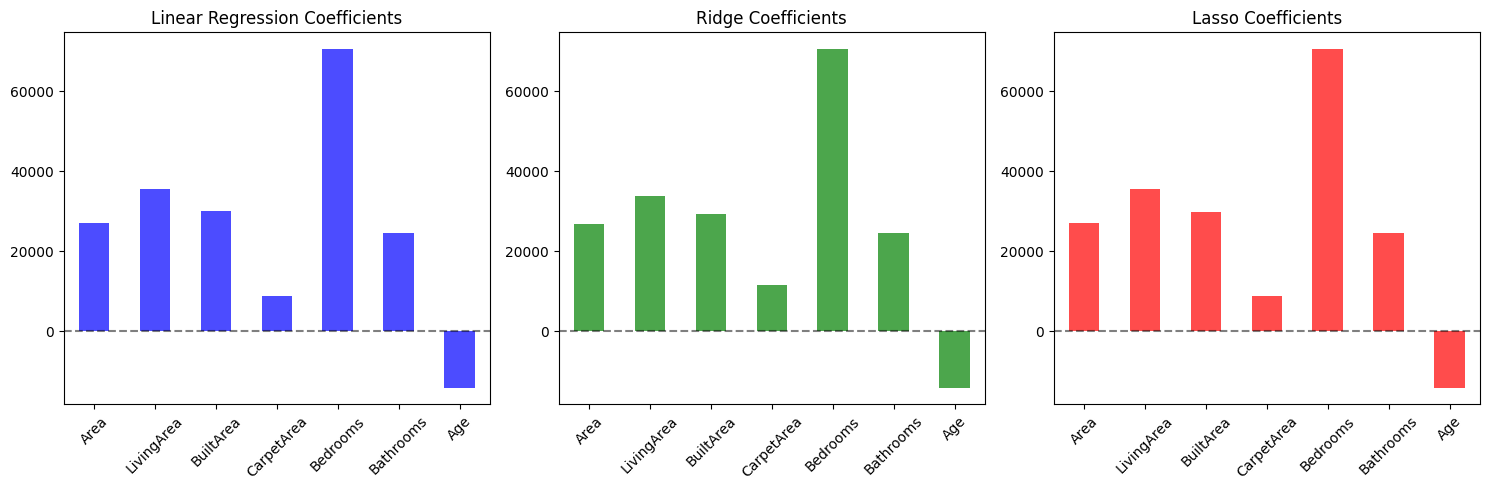


WHY LASSO MIGHT NOT BE SHOWING ZEROS

1. Alpha is too small for strong feature selection
   - Alpha=1 may not be large enough to force coefficients to zero
   - Try larger alphas: 10, 50, 100, 500

2. Data scaling is critical for Lasso
   - Lasso penalizes coefficients based on their magnitude
   - Without scaling, large-scale features dominate the penalty
   - ALWAYS scale data for Lasso!

3. Sample size is large (15,000)
   - With more data, Lasso needs larger alpha to force zeros
   - Large sample size = more evidence = harder to shrink to zero

4. Features are highly correlated (multicollinearity)
   - Lasso struggles with groups of correlated features
   - It might pick one and keep it, or keep small coefficients on all


LASSO COEFFICIENTS AT DIFFERENT ALPHAS

Alpha = 0.01:
Area          27158.0
LivingArea    35616.0
BuiltArea     29993.0
CarpetArea     8880.0
Bedrooms      70557.0
Bathrooms     24690.0
Age          -14030.0
  Features with coefficients near zero: 0

Alpha = 0.1

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Your data creation code (same as before)
np.random.seed(42)
n_samples = 15000
true_area = np.random.normal(2000, 500, n_samples)

Area = true_area + np.random.normal(0, 20, n_samples)
LivingArea = true_area + np.random.normal(0, 30, n_samples)
BuiltArea = true_area + np.random.normal(0, 25, n_samples)
CarpetArea = true_area + np.random.normal(0, 35, n_samples)

Bedrooms = np.random.randint(1, 6, n_samples)
Bathrooms = np.random.randint(1, 4, n_samples)
Age = np.random.randint(0, 50, n_samples)

noise = np.random.normal(0, 50000, n_samples)
price = 200 * true_area + 50000 * Bedrooms + 30000 * Bathrooms - 1000 * Age + noise

df = pd.DataFrame({
    'Area': Area,
    'LivingArea': LivingArea,
    'BuiltArea': BuiltArea,
    'CarpetArea': CarpetArea,
    'Bedrooms': Bedrooms,
    'Bathrooms': Bathrooms,
    'Age': Age,
    'Price': price
})

X = df.drop('Price', axis=1)
y = df['Price']

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# PROPER MODEL COMPARISON
# ============================================

# 1. LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# 2. RIDGE with GridSearch
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_params = {'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]}
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)  # Pipeline handles scaling!

# 3. LASSO with GridSearch (PROPERLY SCALED)
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

lasso_params = {'lasso__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]}
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train, y_train)  # Pipeline handles scaling!

# ============================================
# RESULTS
# ============================================

print("=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)

# Linear Regression
print(f"\nLinear Regression:")
print(f"  R²: {r2_score(y_test, lr_pred):.4f}")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_test, lr_pred)):,.0f}")

# Ridge
ridge_pred = ridge_grid.predict(X_test)
print(f"\nRidge (best alpha = {ridge_grid.best_params_['ridge__alpha']}):")
print(f"  R²: {r2_score(y_test, ridge_pred):.4f}")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_test, ridge_pred)):,.0f}")

# Lasso
lasso_pred = lasso_grid.predict(X_test)
print(f"\nLasso (best alpha = {lasso_grid.best_params_['lasso__alpha']}):")
print(f"  R²: {r2_score(y_test, lasso_pred):.4f}")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_test, lasso_pred)):,.0f}")

# ============================================
# COEFFICIENT COMPARISON
# ============================================

print("\n" + "=" * 60)
print("COEFFICIENT COMPARISON")
print("=" * 60)

# Get coefficients properly
lr_coefs = pd.Series(lr.coef_, index=X.columns)

# Ridge coefficients (from pipeline)
ridge_model = ridge_grid.best_estimator_.named_steps['ridge']
ridge_coefs = pd.Series(ridge_model.coef_, index=X.columns)

# Lasso coefficients (from pipeline)
lasso_model = lasso_grid.best_estimator_.named_steps['lasso']
lasso_coefs = pd.Series(lasso_model.coef_, index=X.columns)

coef_df = pd.DataFrame({
    'Linear': lr_coefs.round(0),
    'Ridge': ridge_coefs.round(0),
    'Lasso': lasso_coefs.round(0)
})

print(coef_df)

# ============================================
# VISUALIZE COEFFICIENTS
# ============================================

'''

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Linear
coef_df['Linear'].plot(kind='bar', ax=axes[0], color='blue', alpha=0.7)
axes[0].set_title('Linear Regression Coefficients')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

# Ridge
coef_df['Ridge'].plot(kind='bar', ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('Ridge Coefficients')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)

# Lasso
coef_df['Lasso'].plot(kind='bar', ax=axes[2], color='red', alpha=0.7)
axes[2].set_title('Lasso Coefficients')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
'''
# ============================================
# WHY LASSO MIGHT NOT SHOW ZEROS
# ============================================

print("\n" + "=" * 60)
print("WHY LASSO MIGHT NOT BE SHOWING ZEROS")
print("=" * 60)

print("""
1. Alpha is too small for strong feature selection
   - Alpha=1 may not be large enough to force coefficients to zero
   - Try larger alphas: 10, 50, 100, 500

2. Data scaling is critical for Lasso
   - Lasso penalizes coefficients based on their magnitude
   - Without scaling, large-scale features dominate the penalty
   - ALWAYS scale data for Lasso!

3. Sample size is large (15,000)
   - With more data, Lasso needs larger alpha to force zeros
   - Large sample size = more evidence = harder to shrink to zero

4. Features are highly correlated (multicollinearity)
   - Lasso struggles with groups of correlated features
   - It might pick one and keep it, or keep small coefficients on all
""")

# Demonstrate with different alpha values
print("\n" + "=" * 60)
print("LASSO COEFFICIENTS AT DIFFERENT ALPHAS")
print("=" * 60)

alphas_to_test = [0.01, 0.1, 1, 10, 50, 100, 500]
lasso_results = {}

for alpha in alphas_to_test:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_results[alpha] = lasso.coef_

# Display results
for alpha in alphas_to_test:
    coefs = pd.Series(lasso_results[alpha], index=X.columns)
    zeros = (coefs.abs() < 1).sum()  # Count near-zero coefficients
    print(f"\nAlpha = {alpha}:")
    print(coefs.round(0).to_string())
    print(f"  Features with coefficients near zero: {zeros}")

In [ ]:
''' info about all '''

'''
Step 1. What are we trying to solve?

Your dataset

Area
LivingArea
BuiltArea
CarpetArea
Bedrooms
Bathrooms
Age

Target

Price

Suppose the real formula is

Price =
200 × Area
+
50000 × Bedrooms
+
30000 × Bathrooms
-
1000 × Age

Only one Area actually matters.

The other three are almost copies.

Area

LivingArea

BuiltArea

CarpetArea

These four are causing

Multicollinearity

Step 2. What does Linear Regression do?

Linear Regression doesn't know which Area is the real one.

So it says

Maybe...

Area gets 27000

LivingArea gets 35000

BuiltArea gets 29000

CarpetArea gets 9000

Notice

It gave

everyone

some credit.

because every Area column looks useful.

Step 3. Ridge

Ridge says

I don't trust huge coefficients.

Instead

27000

↓

25000
35000

↓

30000
29000

↓

26000
9000

↓

10000

Everybody survives.

Nobody dies.

Step 4. Lasso

Lasso says

Instead of

4 Area columns

let's keep only

Area

and remove

LivingArea

BuiltArea

CarpetArea

That is the ideal situation.

But why didn't yours become zero?

This is the important part.

Reason 1

Your alpha is still too small.

Even though GridSearch chose

alpha = 10

that only means

Among YOUR search values

10

was best.

It does NOT mean

10 is large.

For your dataset

maybe

500

1000

5000

would force zeros.

Reason 2

Your dataset is large.

15000 rows

Large datasets contain lots of evidence.

Imagine

LivingArea

really helps prediction.

Lasso thinks

I still need this feature.

So

instead of

0

it becomes

650

or

1200

instead.

Reason 3

All Area columns contain useful information.

You generated

Area

LivingArea

BuiltArea

CarpetArea

like this

true_area
+
tiny noise

Each one

contains

95%

96%

97%

98%

of the real signal.

They're all good predictors.

Lasso has difficulty choosing one because all are similarly informative.

Reason 4

Your alpha search range is too narrow.

Instead of

[0.01,
0.1,
1,
10,
50,
100,
500]

I would try

alphas = np.logspace(-3,5,50)

which becomes

0.001

0.002

0.005

...

100

300

1000

5000

10000

30000

100000

Much better.

Professional workflow

A Senior ML Engineer doesn't immediately run Lasso.

They first ask:

Are features correlated?
corr()

heatmap

VIF

↓

If

0.98

0.99

0.995

they know

Multicollinearity exists.

Then

they ask

Do I care about prediction?

or

Do I care about interpretation?

Case 1

Prediction only

Use

Random Forest

XGBoost

CatBoost

LightGBM

These don't care much about multicollinearity.

Case 2

Interpret coefficients

Use

Ridge

Lasso

ElasticNet
Compare the models
Model	Keeps Features?	Sets to Zero?	Handles Multicollinearity?	Interpretation
Linear	✔	❌	❌	Poor
Ridge	✔	❌	✔	Better
Lasso	Sometimes	✔	✔	Excellent
Elastic Net	✔	✔	✔✔	Best compromise
Why did GridSearch choose alpha = 10?

People misunderstand this.

GridSearch asks

Which alpha

gives

the highest CV score?

Suppose

Alpha	CV R²
0.01	0.8676
0.1	0.8678
1	0.8678
10	0.8679
100	0.865
1000	0.84

It picks

10

because

0.8679

is highest.

It does not try to maximize the number of zero coefficients.

Its objective is prediction performance, not sparsity.

Why doesn't accuracy improve much?

Your synthetic dataset is already almost perfect.

Price

=

true equation

+

small noise

There isn't much to improve.

Models cannot predict the random noise.

So

Linear

R²

0.8678
Ridge

0.8679
Lasso

0.8677

These are almost identical.

That is expected.

How would I make this project more realistic?

Instead of

4 Area columns

I'd generate

50 features

where

10 matter

40 are junk

For example:

Area
LivingArea
BuiltArea
CarpetArea

Bedrooms
Bathrooms

Age

SchoolDistance

CrimeRate

CityPopulation

Then add many irrelevant columns:

RandomNoise1
RandomNoise2
RandomNoise3
...
RandomNoise40

Now Lasso has a real job:

Keep:

Area
Bedrooms
Bathrooms
CrimeRate

Drop:

RandomNoise1

RandomNoise2

RandomNoise3

...

RandomNoise40

This is where Lasso shines.

How to improve model performance professionally

Instead of jumping straight to a different algorithm, work through this checklist:

Improve the data
Collect more representative samples.
Fix missing values thoughtfully.
Remove data-entry errors.
Engineer better features
Create ratios (e.g., PricePerSqFt).
Add interaction terms if appropriate.
Apply log transforms to highly skewed variables.
Handle multicollinearity
Use Ridge or Elastic Net.
Remove duplicate or redundant features if interpretation matters.
Tune hyperparameters
Use GridSearchCV or RandomizedSearchCV.
Search over a wide range of alpha values for Ridge/Lasso.
Choose the right model
Linear problems → Linear/Ridge/Lasso.
Nonlinear relationships → Random Forest, XGBoost, LightGBM, CatBoost.
Evaluate properly
Use cross-validation rather than relying on a single train/test split.
Compare RMSE, MAE, and R² together.
One important ML engineering mindset

A common mistake is to think:

"The model with the highest R² is always the best."

'''